In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import time

# Add the parent directory to Python's path
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import holidays


# Import Pipeline, config, and utilities
import src.config as config
from src.model_prep_tools import ThesisDataPipeline, generate_gap_report

# Set global seeds for notebook reproducibility
config.set_global_seeds()

# Set pandas display options
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')


DATA_DIR = os.path.abspath("../data")
RAW_DIR = os.path.join(DATA_DIR, "raw")
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)


✓ Global random seeds set to 2026


In [2]:
def load_and_prepare(path):
    df = pd.read_csv(path, low_memory=False)
    
    # Parse UTC
    df['Timestamp_UTC'] = pd.to_datetime(df['Timestamp_UTC'], errors='coerce', utc=True)
    
    # Round the minutes
    df['Timestamp_UTC'] = df['Timestamp_UTC'].dt.round('1min') 
    df = df.dropna(subset=['Timestamp_UTC'])
    
    # Convert the rounded UTC time to Greek Local Time
    df['Timestamp_Local'] = df['Timestamp_UTC'].dt.tz_convert('Europe/Athens')
    
    # Set local time as index and sort and drop the original UTC column
    df = df.set_index('Timestamp_Local').sort_index()
    df = df.drop(columns=['Timestamp_UTC'], errors='ignore')
    
    # Clean column names
    df.columns = [c.lower().strip().replace(" ", "_") for c in df.columns]
    
    # Drop purely useless CSV artifacts
    if 'unnamed:_9' in df.columns:
        df = df.drop(columns=['unnamed:_9'])
        
    # Remove duplicate timestamps
    df = df[~df.index.duplicated(keep='first')]
    
    return df

cache_path = os.path.join(PROCESSED_DIR, "step1_merged_grid.parquet")

if os.path.exists(cache_path):
    start = time.time()
    df_patched = pd.read_parquet(cache_path)
    print(f"Shape: {df_patched.shape}")
    
else:
    paths = {
        'battery': os.path.join(RAW_DIR, 'Battery_Energy_Measurements_03.10.2018_30.09.2020.csv'),
        'load': os.path.join(RAW_DIR, 'Load_Consumption_Measurements_03.10.2018_30.09.2020.csv'),
        'pv': os.path.join(RAW_DIR, 'PV_Generation_Measurements_03.10.2018_30.09.2020.csv'),
        'smp': os.path.join(RAW_DIR, 'SMP_Measurements_03.10.2018_30.09.2020.csv'),
        'weather': os.path.join(RAW_DIR, 'Weather_Measurements_03.10.2018_30.09.2020.csv')
    }

    battery = load_and_prepare(paths["battery"])
    load_df = load_and_prepare(paths["load"])
    pv = load_and_prepare(paths["pv"])
    smp = load_and_prepare(paths["smp"])
    weather = load_and_prepare(paths["weather"])

    pipeline = ThesisDataPipeline(target_freq_minutes=15)
    df_grid = pipeline.force_native_grid(load_df, pv, smp, weather, battery=battery)

    if 'energy_consumption' in df_grid.columns:
        df_grid['energy_consumption'] = df_grid['energy_consumption'].clip(lower=0)

    df_patched = pipeline.cross_sensor_patch(df_grid)
    
    # Save to Parquet
    df_patched.to_parquet(cache_path)
    print(f"Final Grid Shape: {df_patched.shape}")

display(df_patched.head())

Aligning datasets and forcing strict 15-min grid

 Cross Sensor Patching and Validation
 [Unit Alignment]: Converted wind_speed_v2 from m/s to km/h
[temperature_v1 & temperature_v2] Spearman Corr: 0.9418
 temperature_v1 and temperature_v2 deviate significantly. So there might be a data quality issue.
Salvaged 8 rows using temperature_v2.
[relative_humidity_v1 & relative_humidity_v2] Spearman Corr: 0.8344
 relative_humidity_v1 and relative_humidity_v2 deviate significantly. So there might be a data quality issue.
Salvaged 8 rows using relative_humidity_v2.
[wind_speed_v1 & wind_speed_v2] Spearman Corr: 0.2467
 wind_speed_v1 and wind_speed_v2 deviate significantly. So there might be a data quality issue.
Salvaged 8 rows using wind_speed_v2.
Final Grid Shape: (69888, 11)


,energy_consumption,energy_generation,smp,temperature_v1,relative_humidity_v1,wind_speed_v1,clouds_v1,clouds_low,clouds_mid,clouds_high,energy_flow_quarter
Timestamp_Local,,,,,,,,,,,
2018-10-04 00:00:00+03:00,0.8,0.0,0.06814,20.6,74.0,3.6,25.0,NaN,NaN,NaN,NaN
2018-10-04 00:15:00+03:00,0.7,0.0,0.06814,20.6,74.0,3.6,0.0,NaN,NaN,NaN,NaN
2018-10-04 00:30:00+03:00,0.7,0.0,0.06814,20.6,74.0,3.6,25.0,NaN,NaN,NaN,NaN
2018-10-04 00:45:00+03:00,0.7,0.0,0.06814,20.6,70.0,3.6,25.0,NaN,NaN,NaN,NaN
2018-10-04 01:00:00+03:00,0.6,0.0,0.08012,22.2,32.0,5.4,25.0,NaN,NaN,NaN,NaN



GAP ANALYSIS REPORT (15-MIN GRID)

[energy_consumption] - Total Missing Rows: 8025
  🟢 Bin 1 (Safe Interpolation, <= 2h):  244 gaps
  🟡 Bin 2 (Causal Day-Type Blend, <= 1w): 47 gaps
  🔴 Bin 3 (Macro-Patch, > 1w):            4 gaps
CRITICAL BIN 3 GAPS FOUND:
From 2019-03-05 09:15:00+02:00 to 2019-03-12 15:45:00+02:00 (699 steps)
From 2020-02-29 00:45:00+02:00 to 2020-03-09 09:45:00+02:00 (901 steps)
From 2020-05-18 09:30:00+03:00 to 2020-05-25 14:30:00+03:00 (693 steps)
From 2020-06-26 14:30:00+03:00 to 2020-07-09 16:30:00+03:00 (1257 steps)

[energy_generation] - Total Missing Rows: 9214
  🟢 Bin 1 (Safe Interpolation, <= 2h):  265 gaps
  🟡 Bin 2 (Causal Day-Type Blend, <= 1w): 52 gaps
  🔴 Bin 3 (Macro-Patch, > 1w):            4 gaps
CRITICAL BIN 3 GAPS FOUND:
From 2019-03-05 09:15:00+02:00 to 2019-03-12 15:45:00+02:00 (699 steps)
From 2020-02-29 00:45:00+02:00 to 2020-03-09 09:45:00+02:00 (901 steps)
From 2020-05-18 09:30:00+03:00 to 2020-05-25 14:30:00+03:00 (693 steps)
From 2020-06-

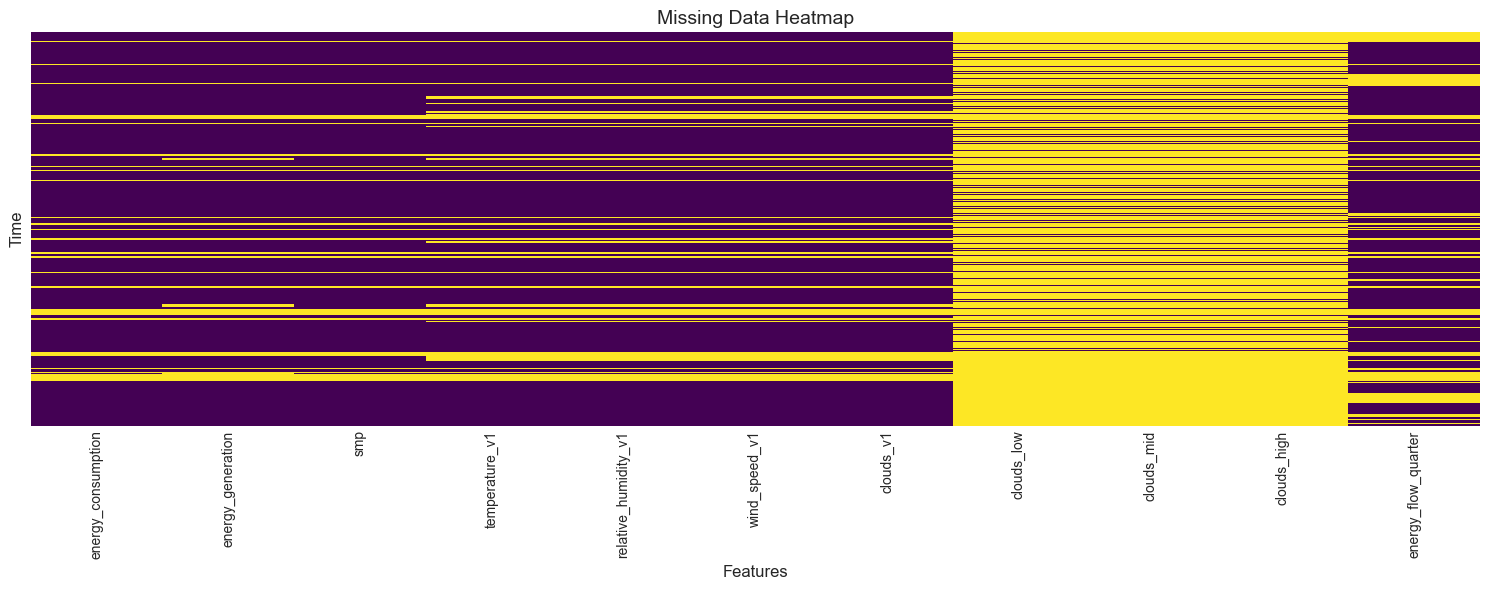

In [3]:
# Run the standalone reporting tool from model_prep_tools
generate_gap_report(df_patched, freq_minutes=15)

# Missing data heatmap (pre-imputation)
plt.figure(figsize=(15, 6))
sns.heatmap(df_patched.isna(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Data Heatmap", fontsize=14)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Time", fontsize=12)
plt.tight_layout()
plt.show()

In [4]:
df_patched.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 69888 entries, 2018-10-04 00:00:00+03:00 to 2020-09-30 23:45:00+03:00
Freq: 15T
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   energy_consumption    61863 non-null  float64
 1   energy_generation     60674 non-null  float64
 2   smp                   61860 non-null  float64
 3   temperature_v1        58083 non-null  float64
 4   relative_humidity_v1  58083 non-null  float64
 5   wind_speed_v1         58083 non-null  float64
 6   clouds_v1             58077 non-null  float64
 7   clouds_low            11625 non-null  float64
 8   clouds_mid            11625 non-null  float64
 9   clouds_high           11625 non-null  float64
 10  energy_flow_quarter   52975 non-null  float64
dtypes: float64(11)
memory usage: 6.4 MB


In [5]:
# Drop the noisy sub-cloud features (~80% missing)
columns_to_drop = ['clouds_low', 'clouds_mid', 'clouds_high']
df_patched = df_patched.drop(columns=[col for col in columns_to_drop if col in df_patched.columns])

print(f"Dropped {columns_to_drop}. Remaining features: {len(df_patched.columns)}")

Dropped ['clouds_low', 'clouds_mid', 'clouds_high']. Remaining features: 8


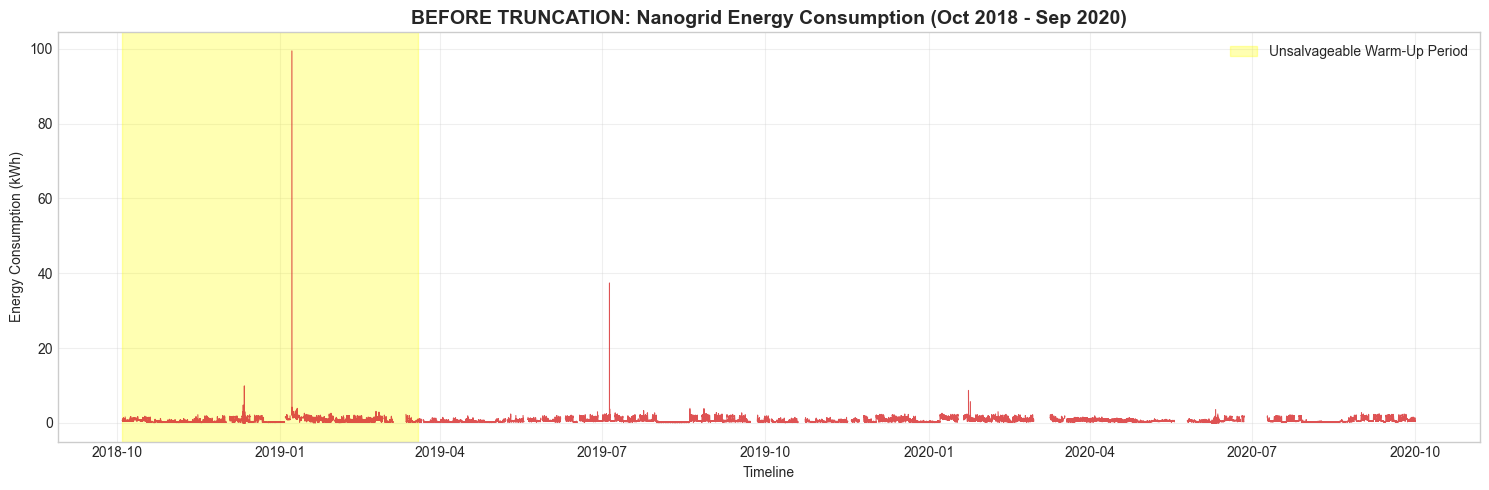

Truncating all corrupted data before: 2019-03-19 12:45:00+02:00

TRUNCATION REPORT:
Original Rows:  69888
Rows Dropped:   15991
Remaining Rows: 53897 (High-Fidelity Data)


In [6]:
# Visualize energy consumption timeline before truncation

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(df_patched.index, df_patched['energy_consumption'], color='#d62728', linewidth=0.8, alpha=0.8)

danger_start = df_patched.index.min()
danger_end = pd.Timestamp('2019-03-19 10:30:00', tz='UTC').tz_convert('Europe/Athens')

ax.axvspan(danger_start, danger_end, color='yellow', alpha=0.3, label='Unsalvageable Warm-Up Period')

ax.set_title('BEFORE TRUNCATION: Nanogrid Energy Consumption (Oct 2018 - Sep 2020)', fontsize=14, fontweight='bold')
ax.set_ylabel('Energy Consumption (kWh)')
ax.set_xlabel('Timeline')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Truncate the dataset to remove the initial warm-up period with corrupted data
# Convert UTC to Local for the slice
clean_start_date = pd.Timestamp('2019-03-19 10:45:00', tz='UTC').tz_convert('Europe/Athens')

print(f"Truncating all corrupted data before: {clean_start_date}")

# Execute the cut
df_truncated = df_patched.loc[clean_start_date:].copy()

print(f"\nTRUNCATION REPORT:")
print(f"Original Rows:  {len(df_patched)}")
print(f"Rows Dropped:   {len(df_patched) - len(df_truncated)}")
print(f"Remaining Rows: {len(df_truncated)} (High-Fidelity Data)")

Causal Imputation Cascade at native 15-min resolution
15-min Master Dataset is 100% continuous. Causal Start Date: 2019-03-19 12:45:00+02:00

 Final Missing Data Check
The dataset is mathematically continuous, without missing values.
Saved Master Dataset to c:\Users\Lefteris\Desktop\Multi – feature time series forecasting for building power load or generation\data\processed\step2_imputed_master.parquet


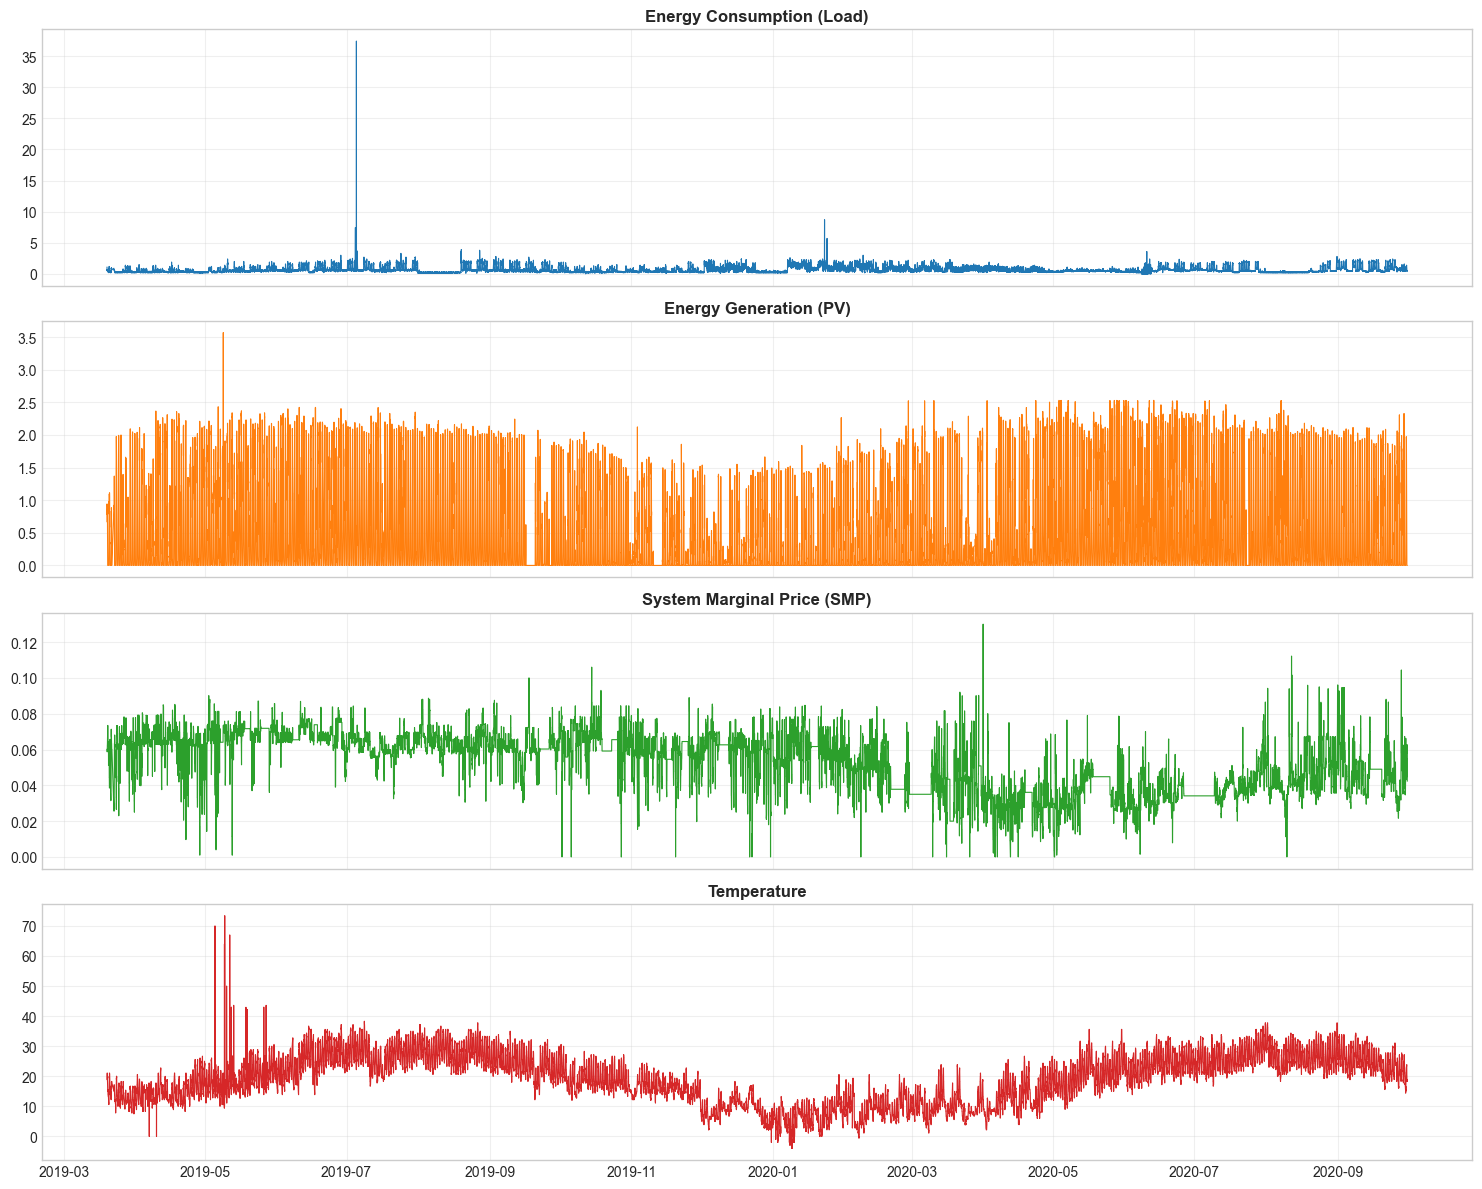

In [7]:
# Casual Bin Imputation

pipeline = ThesisDataPipeline(target_freq_minutes=15)

# Run the core patching algorithm on the truncated dataset
df_imputed = pipeline.temporal_bin_imputation(df_truncated)

print("\n Final Missing Data Check")
remaining_nans = df_imputed.isna().sum().sum()

if remaining_nans == 0:
    print("The dataset is mathematically continuous, without missing values.")
    master_path = os.path.join(PROCESSED_DIR, "step2_imputed_master.parquet")
    df_imputed.to_parquet(master_path)
    print(f"Saved Master Dataset to {master_path}")
    
else:
    print(f"There are still {remaining_nans} missing values to be dealt with.")
    print(df_imputed.isna().sum())


# Multivariate Continuity Check Visualization

cols_to_plot = ['energy_consumption', 'energy_generation', 'smp', 'temperature_v1']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
titles = ['Energy Consumption (Load)', 'Energy Generation (PV)', 'System Marginal Price (SMP)', 'Temperature']

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(15, 12), sharex=True)

for i, col in enumerate(cols_to_plot):
    if col in df_imputed.columns:
        axes[i].plot(df_imputed.index, df_imputed[col], color=colors[i], linewidth=0.8)
        axes[i].set_title(f'{titles[i]}', fontweight='bold')
        axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

[temperature_v1] Detected 76 outliers using window=96, z_thresh=3.5, absolute_thresh=None.
[energy_consumption] Detected 1 outliers using window=96, z_thresh=4.0, absolute_thresh=10.0.
[smp] Detected 162 outliers using window=96, z_thresh=5.0, absolute_thresh=None.
Shape after outlier cleaning: (53816, 8)


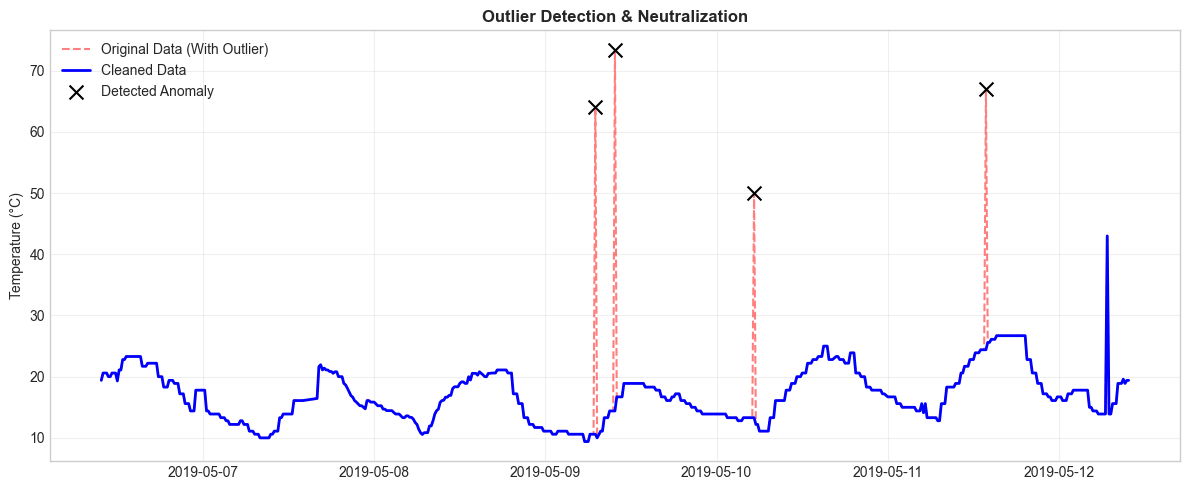

Final Cleaned Master Dataset to c:\Users\Lefteris\Desktop\Multi – feature time series forecasting for building power load or generation\data\processed\step2_imputed_cleaned_master.parquet


In [8]:

# Casual Outlier Detection and Neutralization

def handle_rolling_outliers(df, column, window_steps=96, z_thresh=3.5, absolute_threshold=None):
    # Trailing Window
    rolling_mean = df[column].rolling(window=window_steps, center=False, min_periods=1).mean()
    rolling_std = df[column].rolling(window=window_steps, center=False, min_periods=1).std()
    
    # Calculate Z-Score
    local_z_score = np.abs((df[column] - rolling_mean) / (rolling_std + 1e-8))
    
    # Create mask based on Z-score
    outliers_mask = local_z_score > z_thresh
    
    if absolute_threshold is not None:
        physics_mask = df[column] > absolute_threshold
        outliers_mask = outliers_mask & physics_mask

    outlier_count = outliers_mask.sum()
    print(f"[{column}] Detected {outlier_count} outliers using window={window_steps}, z_thresh={z_thresh}, absolute_thresh={absolute_threshold}.")
    
    # Neutralize and Patch
    df_cleaned = df.copy()
    df_cleaned.loc[outliers_mask, column] = np.nan
    
    # Causal Patching
    df_cleaned[column] = df_cleaned[column].ffill()
    
    return df_cleaned, outliers_mask

# Clean Features
# Cleaning Temperature outliers
df_cleaned, temp_outliers = handle_rolling_outliers(
    df_imputed, 
    'temperature_v1', 
    window_steps=96, 
    z_thresh=3.5
)

if 'energy_consumption' in df_cleaned.columns:
    # Only flag an outlier if Z > 4.0 AND the load is greater than 10 kWh (physically implausible for this nanogrid)
    df_cleaned, load_outliers = handle_rolling_outliers(
        df_cleaned,
        'energy_consumption', 
        window_steps=96, 
        z_thresh=4.0, 
        absolute_threshold=10.0 
    )

if 'smp' in df_cleaned.columns:
    # Price can spike wildly in real markets, so z=5. 
    df_cleaned, smp_outliers = handle_rolling_outliers(df_cleaned, 'smp', window_steps=96, z_thresh=5.0)

print(f"Shape after outlier cleaning: {df_cleaned.shape}")



# Visualization of Outlier Detection & Neutralization

# Find the exact timestamp of the maximum temperature to center our plot
max_temp_idx = df_imputed['temperature_v1'].idxmax()

plot_start = max_temp_idx - pd.Timedelta(days=3)
plot_end = max_temp_idx + pd.Timedelta(days=3)

fig, ax = plt.subplots(figsize=(12, 5))

# Plot the original data (with the spike)
ax.plot(df_imputed.loc[plot_start:plot_end].index, 
        df_imputed.loc[plot_start:plot_end, 'temperature_v1'], 
        color='red', alpha=0.5, label='Original Data (With Outlier)', linestyle='--')

# Plot the cleaned data 
ax.plot(df_cleaned.loc[plot_start:plot_end].index, 
        df_cleaned.loc[plot_start:plot_end, 'temperature_v1'], 
        color='blue', linewidth=2, label='Cleaned Data') 

# Mark the exact outliers
outlier_points = df_imputed.loc[plot_start:plot_end][temp_outliers.loc[plot_start:plot_end]]
ax.scatter(outlier_points.index, outlier_points['temperature_v1'], 
           color='black', marker='x', s=100, label='Detected Anomaly', zorder=5)

ax.set_title(f'Outlier Detection & Neutralization', fontweight='bold')
ax.set_ylabel('Temperature (°C)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final Dataset
master_path = os.path.join(PROCESSED_DIR, "step2_imputed_cleaned_master.parquet")
df_cleaned.to_parquet(master_path)
print(f"Final Cleaned Master Dataset to {master_path}")

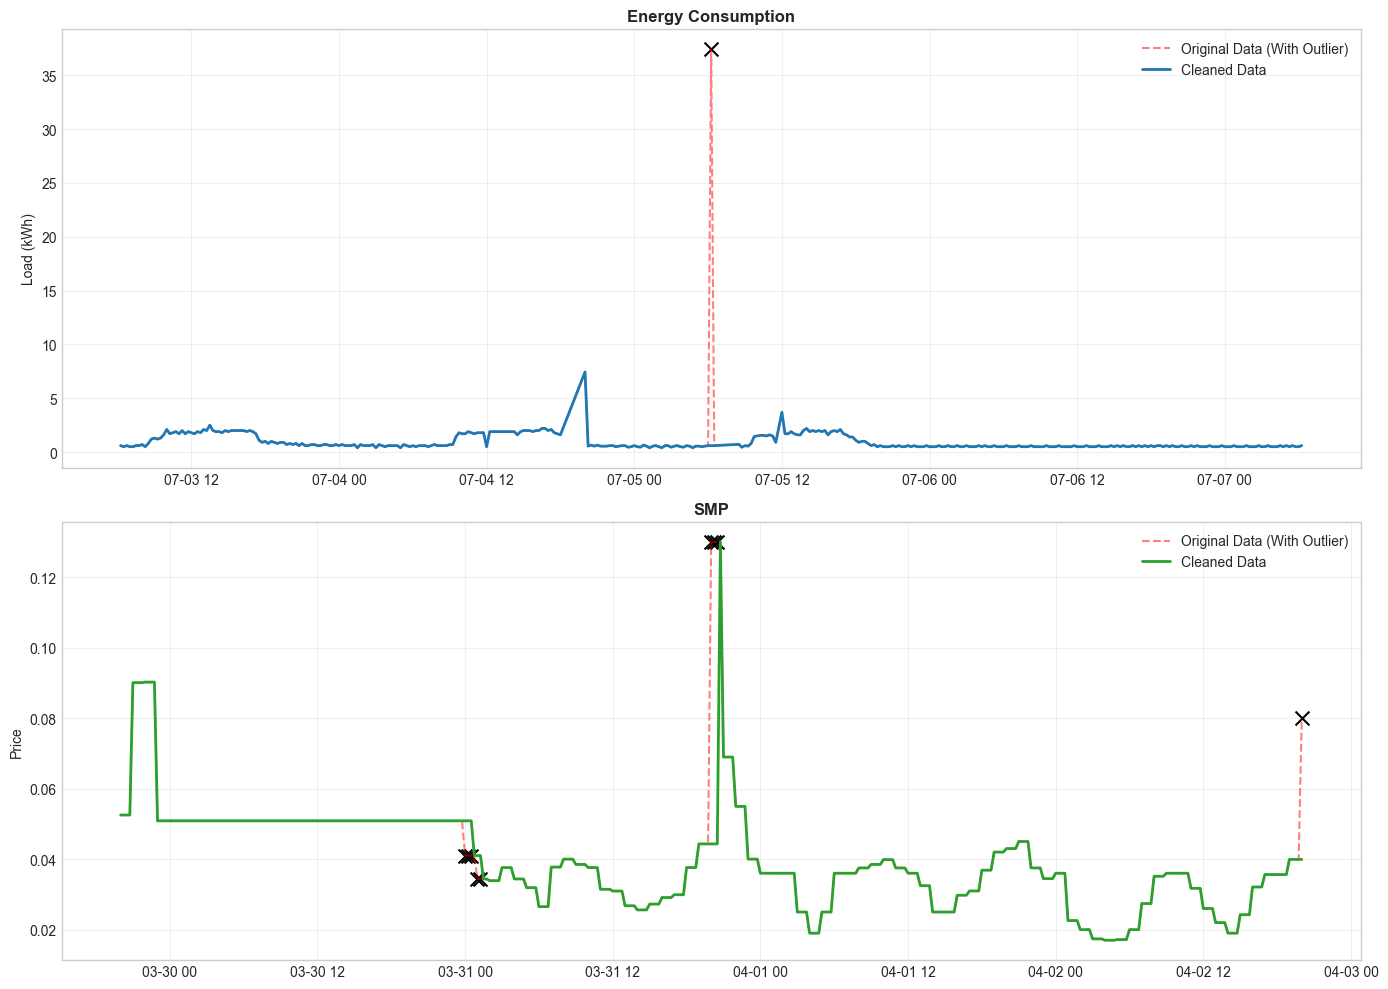

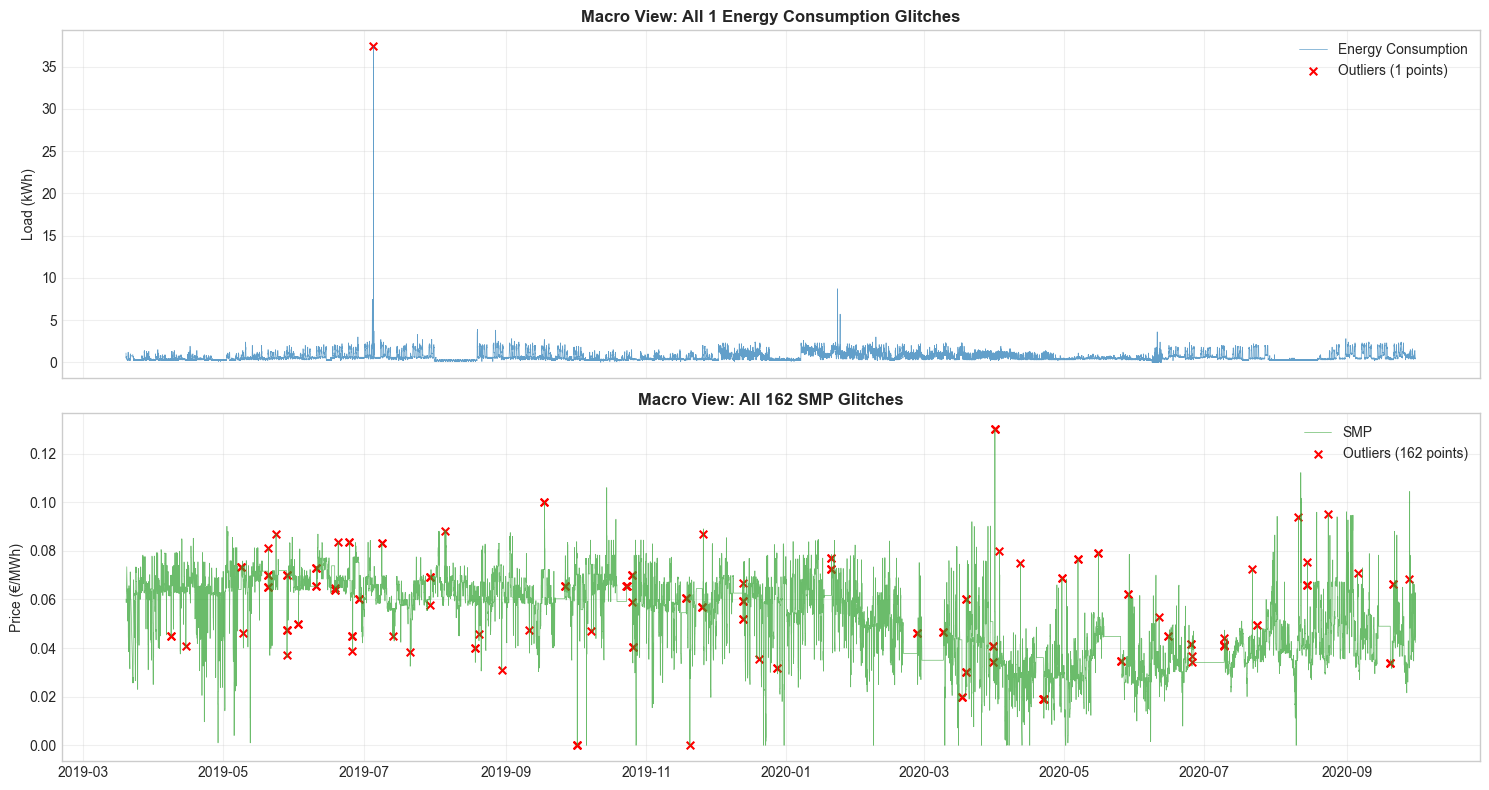

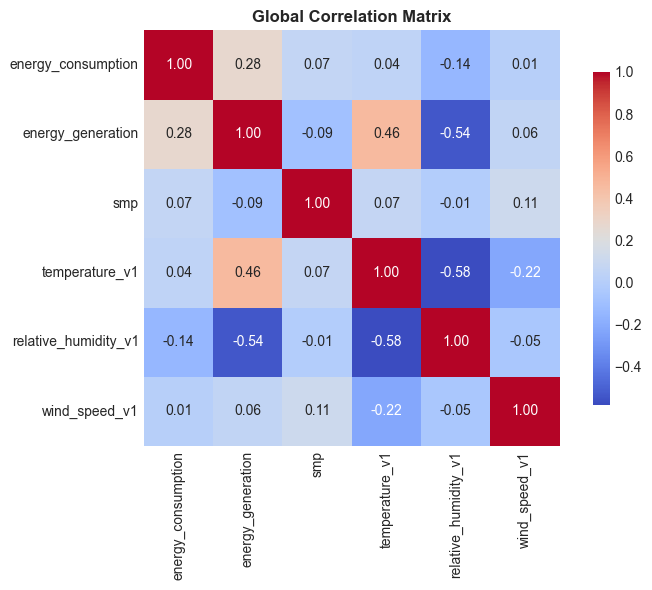

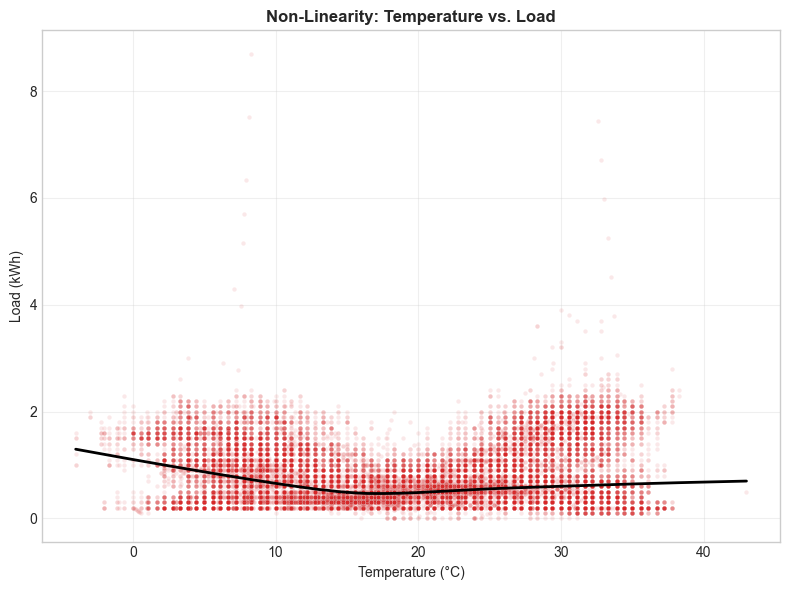

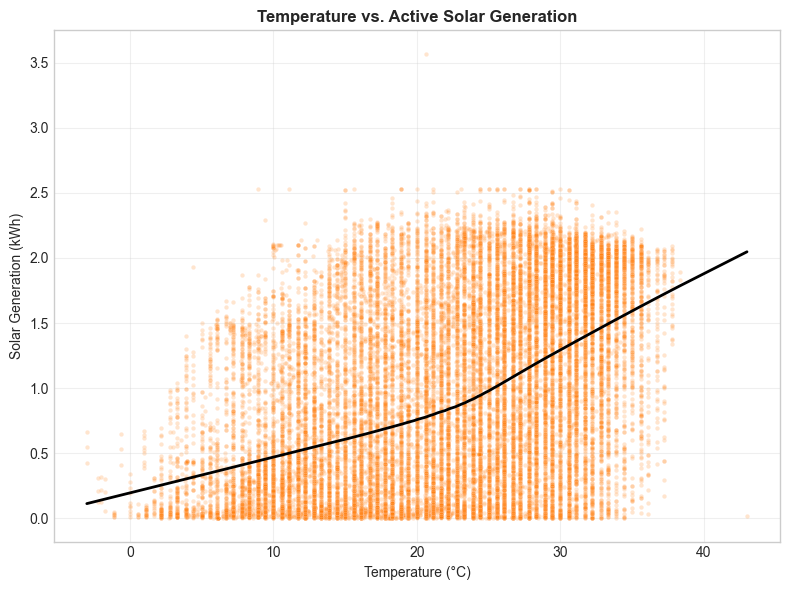

In [ ]:
# Load and SMP Outlier removal visualization

max_load_idx = df_imputed['energy_consumption'].idxmax()
max_smp_idx = df_imputed['smp'].idxmax()

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 10))

# Energy Consumption
plot_start_load = max_load_idx - pd.Timedelta(days=2)
plot_end_load = max_load_idx + pd.Timedelta(days=2)

axes[0].plot(df_imputed.loc[plot_start_load:plot_end_load].index, 
             df_imputed.loc[plot_start_load:plot_end_load, 'energy_consumption'], 
             color='red', alpha=0.5, label='Original Data (With Outlier)', linestyle='--')
axes[0].plot(df_cleaned.loc[plot_start_load:plot_end_load].index, 
             df_cleaned.loc[plot_start_load:plot_end_load, 'energy_consumption'], 
             color='#1f77b4', linewidth=2, label='Cleaned Data')

outliers_load = df_imputed.loc[plot_start_load:plot_end_load][load_outliers.loc[plot_start_load:plot_end_load]]
axes[0].scatter(outliers_load.index, outliers_load['energy_consumption'], color='black', marker='x', s=100)

axes[0].set_title(f'Energy Consumption', fontweight='bold')
axes[0].set_ylabel('Load (kWh)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# System Marginal Price (SMP)
plot_start_smp = max_smp_idx - pd.Timedelta(days=2)
plot_end_smp = max_smp_idx + pd.Timedelta(days=2)

axes[1].plot(df_imputed.loc[plot_start_smp:plot_end_smp].index, 
             df_imputed.loc[plot_start_smp:plot_end_smp, 'smp'], 
             color='red', alpha=0.5, label='Original Data (With Outlier)', linestyle='--')
axes[1].plot(df_cleaned.loc[plot_start_smp:plot_end_smp].index, 
             df_cleaned.loc[plot_start_smp:plot_end_smp, 'smp'], 
             color='#2ca02c', linewidth=2, label='Cleaned Data')

outliers_smp = df_imputed.loc[plot_start_smp:plot_end_smp][smp_outliers.loc[plot_start_smp:plot_end_smp]]
axes[1].scatter(outliers_smp.index, outliers_smp['smp'], color='black', marker='x', s=100)

axes[1].set_title(f'SMP', fontweight='bold')
axes[1].set_ylabel('Price')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



# All detected outliers across the timeline

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 8), sharex=True)

# All Energy Consumption Outliers
axes[0].plot(df_imputed.index, df_imputed['energy_consumption'], color='#1f77b4', linewidth=0.5, alpha=0.7, label='Energy Consumption')

all_load_outliers = df_imputed[load_outliers]
axes[0].scatter(all_load_outliers.index, all_load_outliers['energy_consumption'], color='red', marker='x', s=30, label=f'Outliers ({len(all_load_outliers)} points)')

axes[0].set_title(f'Macro View: All {len(all_load_outliers)} Energy Consumption Glitches', fontweight='bold')
axes[0].set_ylabel('Load (kWh)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# All SMP Outliers
axes[1].plot(df_imputed.index, df_imputed['smp'], color='#2ca02c', linewidth=0.5, alpha=0.7, label='SMP')

all_smp_outliers = df_imputed[smp_outliers]
axes[1].scatter(all_smp_outliers.index, all_smp_outliers['smp'], color='red', marker='x', s=30, label=f'Outliers ({len(all_smp_outliers)} points)')

axes[1].set_title(f'Macro View: All {len(all_smp_outliers)} SMP Glitches', fontweight='bold')
axes[1].set_ylabel('Price (€/MWh)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



# Correlation heatmap
plt.figure(figsize=(8, 6))

corr_cols = ['energy_consumption', 'energy_generation', 'smp', 'temperature_v1', 
             'relative_humidity_v1', 'wind_speed_v1']
valid_corr_cols = [c for c in corr_cols if c in df_cleaned.columns]

sns.heatmap(df_cleaned[valid_corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", 
            cbar_kws={'shrink': .8}, square=True)

plt.title('Global Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()



# Proof of non-linearity: Temperature vs. Load (The U-Curve)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_cleaned['temperature_v1'], y=df_cleaned['energy_consumption'], 
                alpha=0.1, color='#d62728', s=10)
sns.regplot(x=df_cleaned['temperature_v1'], y=df_cleaned['energy_consumption'], 
            scatter=False, color='black', lowess=True, line_kws={'linewidth': 2})

plt.title('Non-Linearity: Temperature vs. Load', fontweight='bold')
plt.xlabel('Temperature (°C)')
plt.ylabel('Load (kWh)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



# Temperature vs. Solar Generation (PV Physics)

plt.figure(figsize=(8, 6))
daytime_pv = df_cleaned[df_cleaned['energy_generation'] > 0]

sns.scatterplot(x=daytime_pv['temperature_v1'], y=daytime_pv['energy_generation'], 
                alpha=0.2, color='#ff7f0e', s=10)
sns.regplot(x=daytime_pv['temperature_v1'], y=daytime_pv['energy_generation'], 
            scatter=False, color='black', lowess=True, line_kws={'linewidth': 2})

plt.title('Temperature vs. Active Solar Generation', fontweight='bold')
plt.xlabel('Temperature (°C)')
plt.ylabel('Solar Generation (kWh)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

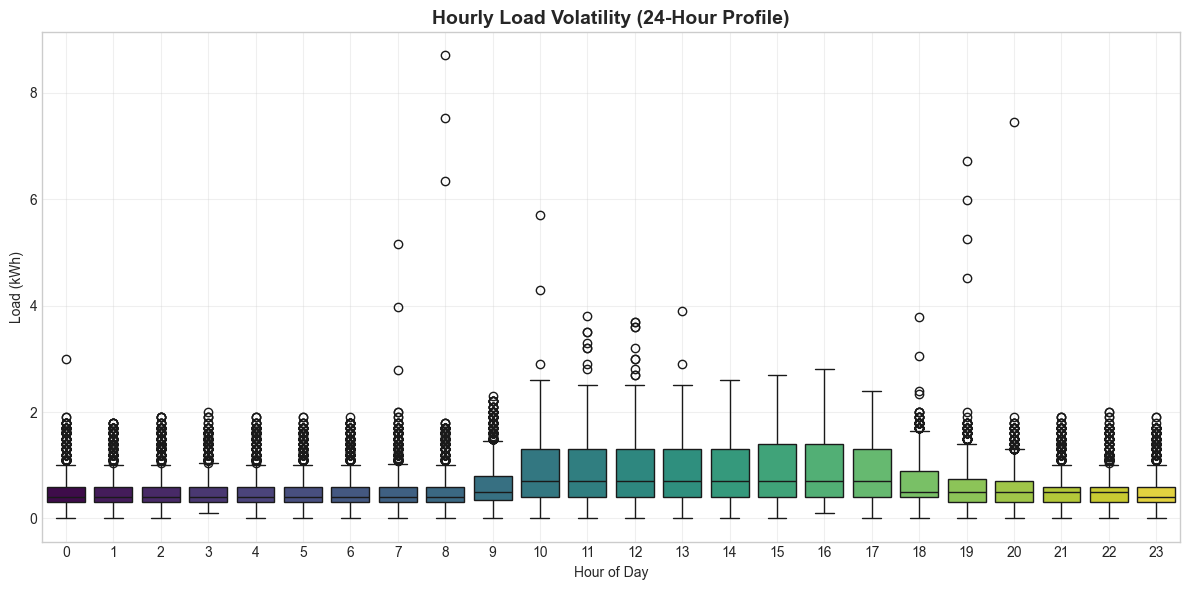

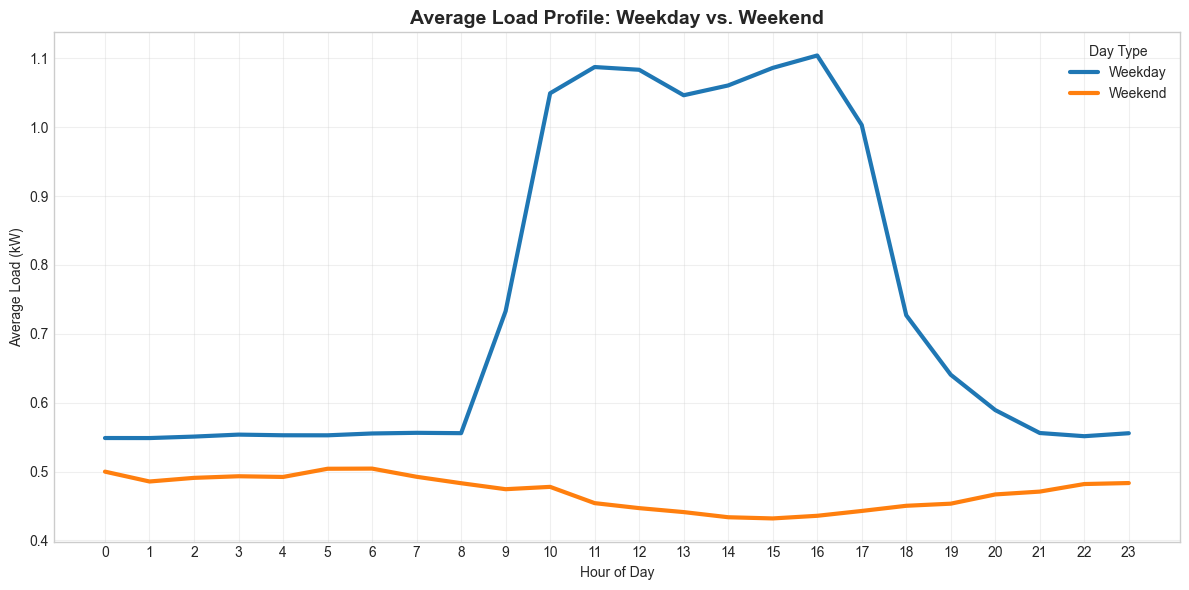

In [10]:

# feature extraction for EDA

df_eda = df_cleaned.copy()
df_eda['Hour'] = df_eda.index.hour
df_eda['DayOfWeek'] = df_eda.index.dayofweek
df_eda['Is_Weekend'] = df_eda['DayOfWeek'].isin([5, 6]).astype(int)


# Hourly Volatility Boxplot

plt.figure(figsize=(12, 6))

sns.boxplot(x='Hour', y='energy_consumption', data=df_eda, palette='viridis', hue='Hour', legend=False)

plt.title('Hourly Load Volatility (24-Hour Profile)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Load (kWh)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Weekday vs. Weekend Average Profile visualization

plt.figure(figsize=(12, 6))

# Group by Hour and Weekend status
hourly_avg = df_eda.groupby(['Hour', 'Is_Weekend'])['energy_consumption'].mean().reset_index()

sns.lineplot(x='Hour', y='energy_consumption', hue='Is_Weekend', data=hourly_avg, 
             linewidth=3, palette=['#1f77b4', '#ff7f0e'])

plt.title('Average Load Profile: Weekday vs. Weekend', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Average Load (kW)')
plt.xticks(range(0, 24, 1))

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Weekday', 'Weekend'], title='Day Type')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

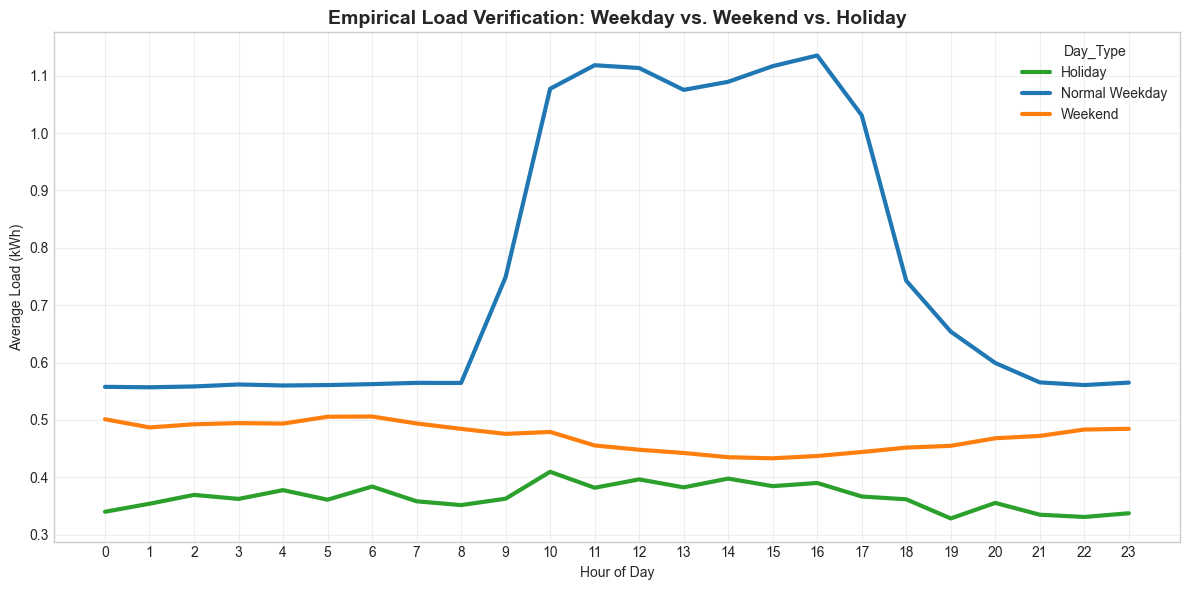

Day_Type
Holiday           0.365906
Normal Weekday    0.760222
Weekend           0.471905
Name: energy_consumption, dtype: float64


In [11]:

# Weekday vs. Weekend vs. Holiday (Decide if we should include an is_work_day feature)

df_holiday_eda = df_cleaned.copy()
df_holiday_eda['Hour'] = df_holiday_eda.index.hour

# Fetch Greek Holidays
years_in_data = df_holiday_eda.index.year.unique().tolist()
gr_holidays = holidays.country_holidays('GR', years=years_in_data)

# Map the DatetimeIndex to the holiday dictionary
holiday_mask = df_holiday_eda.index.map(lambda x: x in gr_holidays)
weekend_mask = df_holiday_eda.index.dayofweek.isin([5, 6])

# Categorize
conditions = [holiday_mask, weekend_mask]
choices = ['Holiday', 'Weekend']
df_holiday_eda['Day_Type'] = np.select(conditions, choices, default='Normal Weekday')


# Plotting the profiles
plt.figure(figsize=(12, 6))

# Group by Hour and Day_Type
hourly_profiles = df_holiday_eda.groupby(['Hour', 'Day_Type'])['energy_consumption'].mean().reset_index()

color_map = {
    'Normal Weekday': '#1f77b4',
    'Weekend': '#ff7f0e',
    'Holiday': '#2ca02c'
}

sns.lineplot(x='Hour', y='energy_consumption', hue='Day_Type', data=hourly_profiles, 
             linewidth=3, palette=color_map)

plt.title('Empirical Load Verification: Weekday vs. Weekend vs. Holiday', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Average Load (kWh)')
plt.xticks(range(0, 24, 1))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistical summary
baseloads = df_holiday_eda.groupby('Day_Type')['energy_consumption'].mean()
print(baseloads)

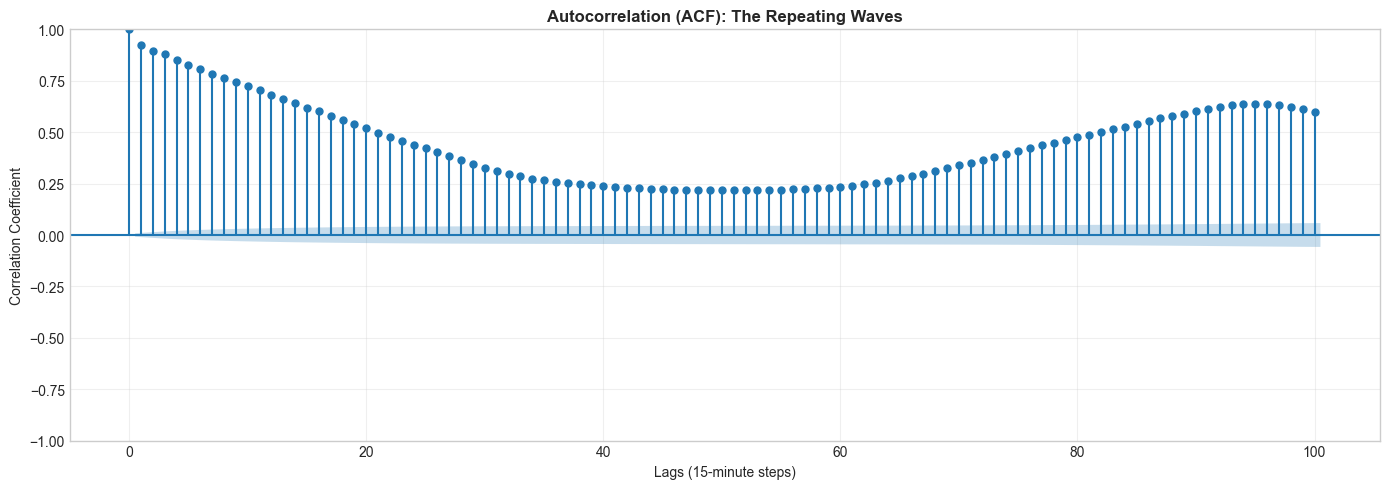

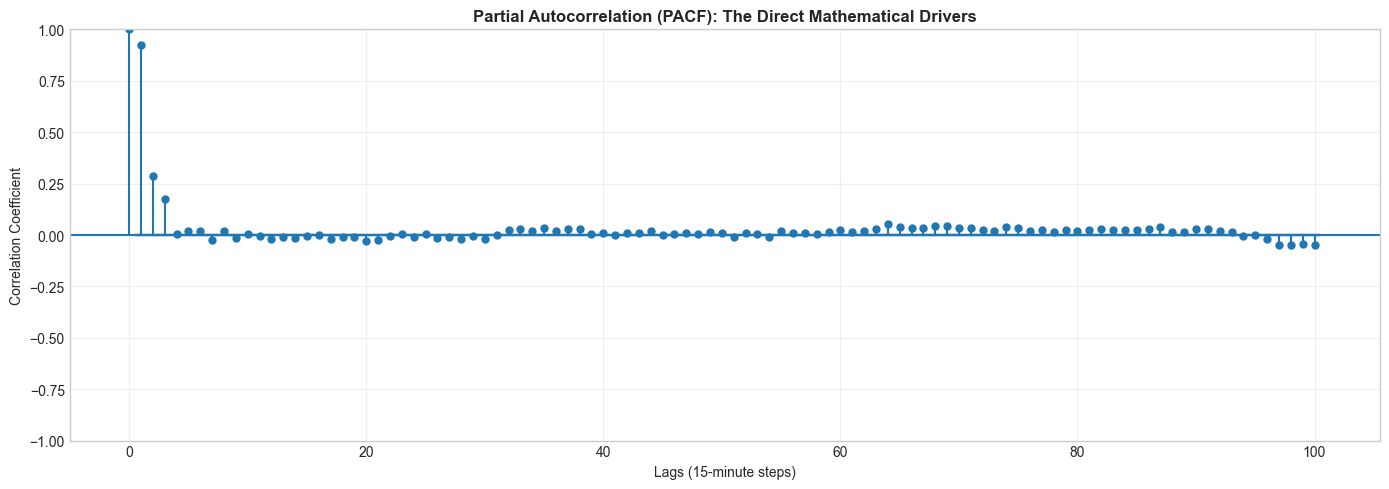

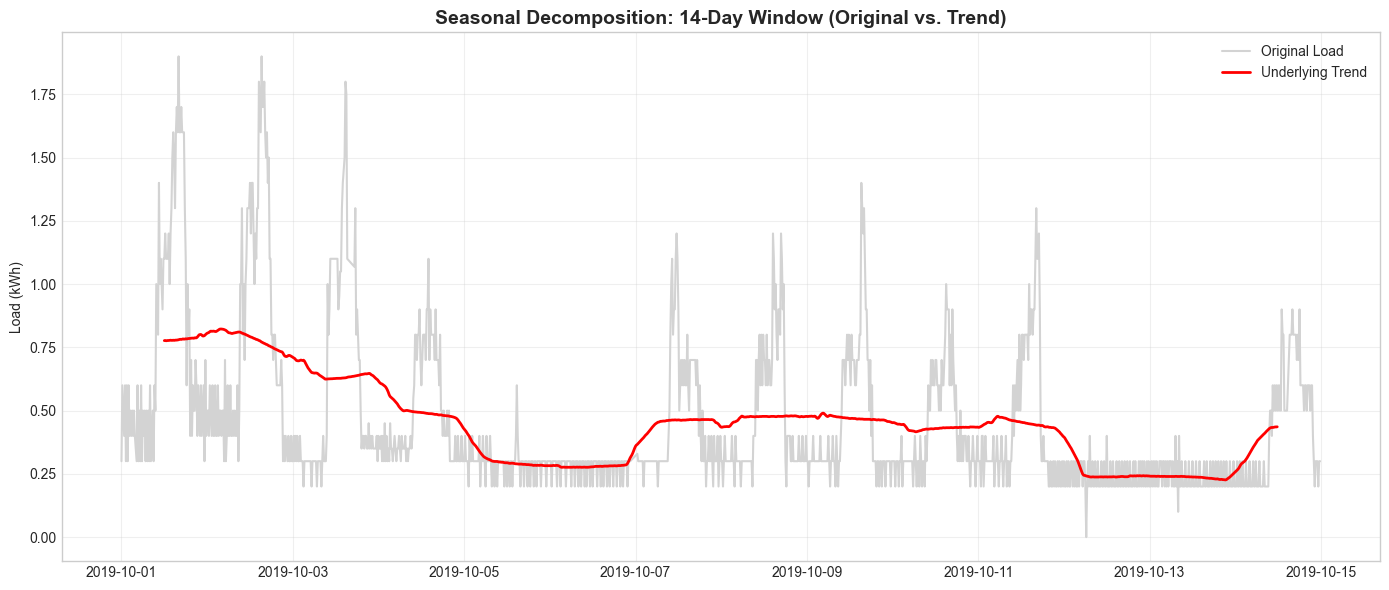

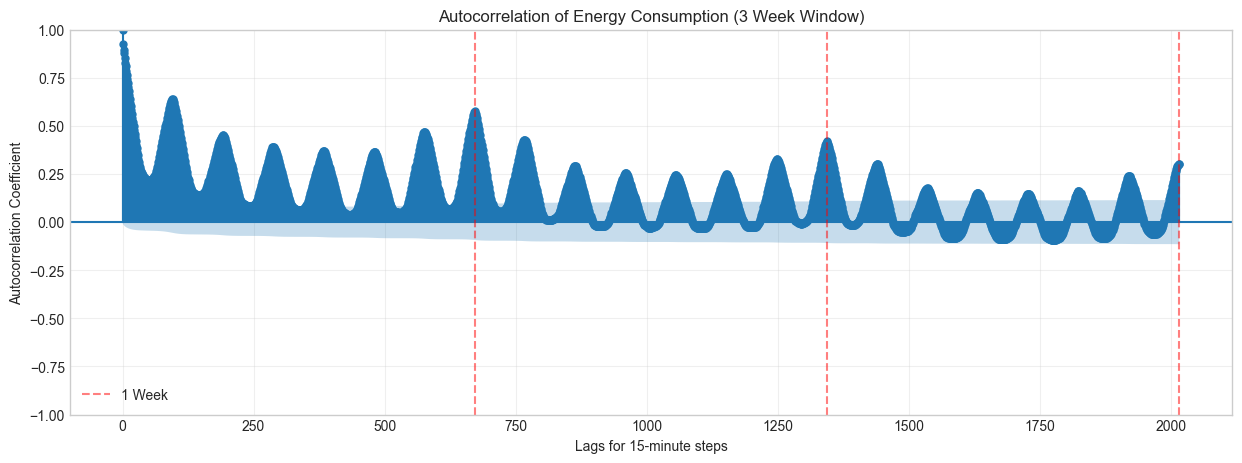

In [12]:
# Autocorrelation Function (ACF) visualization

fig, ax = plt.subplots(figsize=(14, 5))

# 100 lags = 25 hours (at 15-min freq)
plot_acf(df_cleaned['energy_consumption'], lags=100, ax=ax, alpha=0.05)

ax.set_title('Autocorrelation (ACF): The Repeating Waves', fontweight='bold')
ax.set_xlabel('Lags (15-minute steps)')
ax.set_ylabel('Correlation Coefficient')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Partial Autocorrelation Function (PACF) visualization

fig, ax = plt.subplots(figsize=(14, 5))

plot_pacf(df_cleaned['energy_consumption'], lags=100, ax=ax, alpha=0.05, method='ywm')

ax.set_title('Partial Autocorrelation (PACF): The Direct Mathematical Drivers', fontweight='bold')
ax.set_xlabel('Lags (15-minute steps)')
ax.set_ylabel('Correlation Coefficient')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Seasonal Decomposition (14-Day Window)

plt.figure(figsize=(14, 6))

# We take a 14-day slice in a stable month (e.g., October 2019)
slice_start = '2019-10-01'
slice_end = '2019-10-14'
df_slice = df_cleaned.loc[slice_start:slice_end, 'energy_consumption']

# period=96 because 96 * 15-mins = 24 hours
decomp = seasonal_decompose(df_slice, model='additive', period=96)

plt.plot(df_slice.index, df_slice.values, label='Original Load', color='lightgrey')
plt.plot(decomp.trend.index, decomp.trend.values, label='Underlying Trend', color='red', linewidth=2)

plt.title('Seasonal Decomposition: 14-Day Window (Original vs. Trend)', fontsize=14, fontweight='bold')
plt.ylabel('Load (kWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Autocorrelation of Energy Consumption for 3 Weeks

lags_to_plot = 96*21
plt.figure(figsize=(15,5))
plot_acf(df_cleaned['energy_consumption'].dropna(), lags = lags_to_plot, alpha=0.05, ax=plt.gca())
plt.title("Autocorrelation of Energy Consumption (3 Week Window)")
plt.xlabel("Lags for 15-minute steps")
plt.ylabel("Autocorrelation Coefficient")

for week in range(1,4):
    plt.axvline(x=96*7*week, color='red', linestyle = '--', alpha = 0.5, label = '1 Week' if week==1 else "")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
df_final = df_cleaned.copy() 

# Calculate the time difference between every single row in df_final
deltas = df_final.index.to_series().diff()

# Find any jump that is strictly greater than 15 minutes
broken_points = deltas[deltas > pd.Timedelta(minutes=15)]

if len(broken_points) > 0:
    print("Timeline jumps located at:")
    for timestamp, delta in broken_points.items():
        print(f"Jump of {delta} occurred ending at -> {timestamp}")
else:
    print("No gaps greater than 15 minutes found.")


print("\nContinuity fix on df_final")
print(f"Shape before fix: {df_final.shape}")

# Expose the exact missing rows as explicit NaNs
df_final = df_final.resample('15min').asfreq()

# Try to patch using exactly 1 week ago
df_final = df_final.fillna(df_final.shift(96 * 7))

# If 1 week ago was also a blackout, reach back 2 weeks!
df_final = df_final.fillna(df_final.shift(96 * 14))

# Final safety net: FORWARD FILL for strictly causal micro-gap bridging
df_final = df_final.ffill()

# Drop any lingering NaNs at the absolute beginning of the dataset
df_final = df_final.dropna()

print(f"Shape after fix:  {df_final.shape}")
print("Fix Complete. Timeline is now mathematically continuous.\n")

Timeline jumps located at:
Jump of 0 days 20:30:00 occurred ending at -> 2019-03-22 12:15:00+02:00

Continuity fix on df_final
Shape before fix: (53816, 8)
Shape after fix:  (53897, 8)
Fix Complete. Timeline is now mathematically continuous.



In [14]:
# Rigor check function to audit the final engineered datasets before saving. It checks for perfect continuity, absence of NaNs, and presence of expected features like 1-week lags.

def rigor_check(df, name, expected_freq_mins):
    print(f"AUDITING: {name} DATASET")
    
    deltas = df.index.to_series().diff().dropna()
    unique_deltas = deltas.unique()
    expected_delta = pd.Timedelta(minutes=expected_freq_mins)
    
    if len(unique_deltas) == 1 and unique_deltas[0] == expected_delta:
        print(f"Perfect continuity.")
    else:
        print(f"Broken Timeline. Found unexpected time jumps: {unique_deltas}")
        
    total_nans = df.isna().sum().sum()
    if total_nans == 0:
        print(f"NaN Check:0 missing values")
    else:
        print(f"Found {total_nans} NaNs in the dataset.")

    # Check for the 1-week lag
    if "energy_consumption_lag_1w" in df.columns:
        print(f"Features: 1-week lags present")
    else:
        print(f"Missing expected lags")
        
    print(f"Final Size: {df.shape[0]} rows | {df.shape[1]} features.")

# Physics-Based Conversion: Energy (kWh) to Average Power (kW) so we can compare models for the 15 minute, 30 minute and 60 minute horizons on the same target variable using mean().
# 15 mins = 0.25 hours, therefore Average Power (kW) = Energy (kWh) * 4
df_converted = df_final.copy()

if 'energy_consumption' in df_converted.columns:
    df_converted['energy_consumption'] = df_converted['energy_consumption'] * 4
    
if 'energy_generation' in df_converted.columns:
    df_converted['energy_generation'] = df_converted['energy_generation'] * 4
    
print("Physics Conversion Complete: Target variables are now strictly Average Power (kW).\n")

# Generation of the final 15-min, 30-min and 60-min datasets.

horizons = [15, 30, 60]
final_datasets = {}

for horizon in horizons:
    print(f"\n[INITIATING {horizon}-MIN PIPELINE]")
    
    pipeline = ThesisDataPipeline(target_freq_minutes=horizon)
    df_engineered = pipeline.resample_and_engineer(df_converted)
    
    rigor_check(df_engineered, f"{horizon}-Min", horizon)
    
    # Saved to Parquet
    save_path = os.path.join(PROCESSED_DIR, f'nanogrid_{horizon}min_features.parquet')
    df_engineered.to_parquet(save_path)
    print(f"Saved dataset to: {save_path}")
    
    final_datasets[horizon] = df_engineered

Physics Conversion Complete: Target variables are now strictly Average Power (kW).


[INITIATING 15-MIN PIPELINE]
Resampling to 15min with 24h Action Lead Time
AUDITING: 15-Min DATASET
Perfect continuity.
NaN Check:0 missing values
Features: 1-week lags present
Final Size: 53225 rows | 22 features.
Saved dataset to: c:\Users\Lefteris\Desktop\Multi – feature time series forecasting for building power load or generation\data\processed\nanogrid_15min_features.parquet

[INITIATING 30-MIN PIPELINE]
Resampling to 30min with 24h Action Lead Time
AUDITING: 30-Min DATASET
Perfect continuity.
NaN Check:0 missing values
Features: 1-week lags present
Final Size: 26613 rows | 23 features.
Saved dataset to: c:\Users\Lefteris\Desktop\Multi – feature time series forecasting for building power load or generation\data\processed\nanogrid_30min_features.parquet

[INITIATING 60-MIN PIPELINE]
Resampling to 60min with 24h Action Lead Time
AUDITING: 60-Min DATASET
Perfect continuity.
NaN Check:0 missing value

In [15]:
# Final sanity check on the 15-min dataset to confirm perfect continuity, presence of key features, and correct timezone handling before we move on to modeling.
df_check = pd.read_parquet(os.path.join(PROCESSED_DIR, 'nanogrid_15min_features.parquet'))

print(f"Shape: {df_check.shape} (Rows, Features)\n")

print("Index Details:")
print(f"Type: {type(df_check.index)}")
print(f"Timezone: {df_check.index.tz}")
print(f"Start: {df_check.index.min()}")
print(f"End:   {df_check.index.max()}\n")

print(" Target & Features Check:")
# Removed the obsolete 24h lag from the check
cols_to_check = ['energy_consumption', 'energy_consumption_lag_1w', 'hour_sin', 'day_sin']
for col in cols_to_check:
    if col in df_check.columns:
        print(f" {col} is present.")
    else:
        print(f" Missing: {col}")

print("\n First 5 Rows (To check feature alignment):")
display(df_check.head(5))

Shape: (53225, 22) (Rows, Features)

Index Details:
Type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Timezone: Europe/Athens
Start: 2019-03-26 12:45:00+02:00
End:   2020-09-30 23:45:00+03:00

 Target & Features Check:
 energy_consumption is present.
 energy_consumption_lag_1w is present.
 hour_sin is present.
 day_sin is present.

 First 5 Rows (To check feature alignment):


,energy_consumption,energy_generation,smp,temperature_v1,relative_humidity_v1,wind_speed_v1,clouds_v1,energy_flow_quarter,energy_consumption_lag_1w,energy_generation_lag_1w,smp_lag_1w,temperature_v1_lag_1w,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,temp_x_hour,is_holiday,is_weekend,is_non_working_day
Timestamp_Local,,,,,,,,,,,,,,,,,,,,,,
2019-03-26 12:45:00+02:00,2.8,4.248001,0.06356,17.8,41.0,4.824,45.0,-0.004109,4.4,2.672001,0.06014,18.9,-0.195090,-0.980785,0.781831,0.62349,1.0,6.123234e-17,-3.472608,0,0,0
2019-03-26 13:00:00+02:00,2.4,4.995994,0.06470,18.3,40.0,4.824,100.0,-0.004344,2.4,3.040001,0.06010,19.4,-0.258819,-0.965926,0.781831,0.62349,1.0,6.123234e-17,-4.736389,0,0,0
2019-03-26 13:15:00+02:00,2.4,2.324005,0.06470,17.8,40.0,8.064,100.0,-0.004104,2.8,3.770534,0.06010,19.4,-0.321439,-0.946930,0.781831,0.62349,1.0,6.123234e-17,-5.721622,0,0,0
2019-03-26 13:30:00+02:00,2.4,1.675995,0.06470,17.8,40.0,4.824,100.0,-0.004100,2.0,3.287000,0.06010,20.0,-0.382683,-0.923880,0.781831,0.62349,1.0,6.123234e-17,-6.811765,0,0,0
2019-03-26 13:45:00+02:00,2.0,1.348007,0.06470,17.8,42.0,4.824,100.0,-0.004102,2.4,3.226400,0.06010,20.0,-0.442289,-0.896873,0.781831,0.62349,1.0,6.123234e-17,-7.872739,0,0,0
